In [1]:
import pandas as pd
df = pd.read_csv("MD_agric_exam-4313.csv")

In [2]:
print(df.columns)

Index(['Field_ID', 'Elevation', 'Rainfall', 'Min_temperature_C',
       'Max_temperature_C', 'pH', 'Pollution_level', 'Plot_size',
       'Annual_yield', 'Crop_type'],
      dtype='object')


In [5]:
unique_crops = df["Crop_type"].nunique()
print(unique_crops)


8


In [11]:
wheat_max = df.loc[df["Crop_type"] == "wheat", "Annual_yield"].max()
print(round(wheat_max, 2))

8.99


In [12]:
total_rainfall = df[df["Pollution_level"]> 0.2]["Rainfall"].sum()
total_rainfall

478902.6

In [13]:
def temperature_range(df, field_id):
    row = df[df["Field_ID"] == field_id]
    return row["Max_temperature_C"].values[0] - row["Min_temperature_C"].values[0]

In [14]:
print(temperature_range(df, 1458))
print(temperature_range(df, 1895))
print(temperature_range(df, 5443))

40.7
35.7
33.4


In [15]:
a = data['Crop_type'].unique()

b = float('inf')

c = ''

for crop in a:

    d = data[data['Crop_type'] == crop]['Min_temperature_C'].mean()

    if d < b:

        b = d

        c = crop

print(c)

NameError: name 'data' is not defined

In [16]:
plot = df[df["pH"]<5.5]["Plot_size"].sum()
plot

1731.8999999999999

In [17]:
filtered_df = df[(df["Min_temperature_C"] < -5) & (df["Max_temperature_C"] > 30)]
len(filtered_df)

319

In [18]:
import numpy as np
import pandas as pd

median_size = df["Plot_size"].median()
filtered_rainfall = df[df["Plot_size"] > median_size]["Rainfall"]

std_value = np.std(filtered_rainfall)
round(std_value, 2)

469.62

In [19]:
most_common_temp = df["Max_temperature_C"].mode()[0]
temp_part = str(most_common_temp)[:3]

least_common_crop = df["Crop_type"].value_counts().idxmin()
crop_part = least_common_crop[-3:]

result = temp_part + crop_part
result

'30.ice'

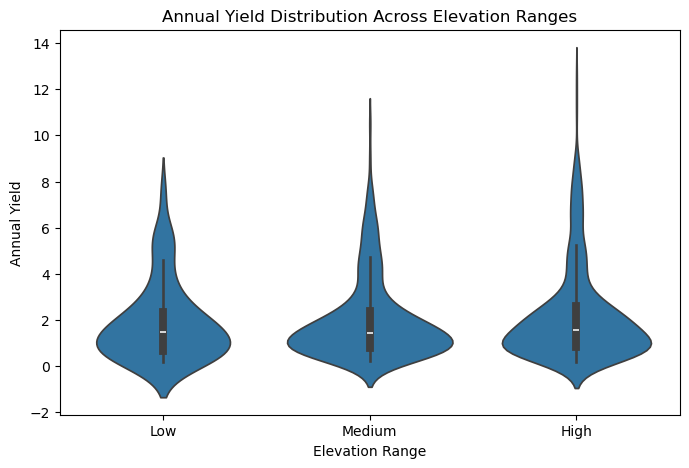

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create elevation categories
def categorize_elevation(elev):
    if elev < 300:
        return "Low"
    elif elev <= 600:
        return "Medium"
    else:
        return "High"

df["Elevation_range"] = df["Elevation"].apply(categorize_elevation)

# Create violin plot
plt.figure(figsize=(8,5))
sns.violinplot(x="Elevation_range", y="Annual_yield", data=df, order=["Low", "Medium", "High"])

plt.title("Annual Yield Distribution Across Elevation Ranges")
plt.xlabel("Elevation Range")
plt.ylabel("Annual Yield")
plt.show()

In [21]:
def crop_sum(crops, i=0):
    # base case
    if i == len(crops):
        return 0
    
    # recursive case
    return len(crops[i]) + crop_sum(crops, i + 1)

unique_crops = df["Crop_type"].unique()
result = crop_sum(unique_crops)
result

42

In [23]:
import pandas as pd
from scipy import stats

# Load your dataset (replace with actual file or dataframe)
df = pd.read_csv("MD_agric_exam-4313.csv")

# Filter the two crop types
coffee_yield = df[df["Crop_type"] == "coffee"]["Annual_yield"]
banana_yield = df[df["Crop_type"] == "banana"]["Annual_yield"]

# Perform independent t-test (Welch’s t-test by default if equal_var=False)
t_stat, p_value = stats.ttest_ind(coffee_yield, banana_yield, equal_var=False)

# Print rounded p-value
print(round(p_value, 3))

0.598
